In [29]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcol
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

plt.style.use('./presentation.mplstyle')

In [30]:
gls = sim(exgrp_fields=['GroupFirstSub'],exsub_fields=['SubhaloMass','SubhaloStellarPhotometrics','SubhaloMassType'])
sim.mass_add(gls)

/Users/bhattacharyya.37/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/bhattacharyya.37/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [31]:
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5,hfloor=10):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,thresh,floor)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
    back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
    back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    x200 = [[],[],[]]

    all_gal_pos =  gls.sub.SubhaloPos[all_gal,:]
    massive_gal_pos = gls.sub.SubhaloPos[massive_gal,:] 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        blh = (np.where(j==back_gal)[0])[0]
        if gls.hst.group_m200[lh]>=hfloor and gls.hst.group_m200[lh]<11.5 and gls.sub.mst[j]<thresh and gls.sub.mst[j]>floor:
                #dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                    
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
                          
                dhost[2].append(dist[0])
                llt[2].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                x200[2].append(back_dz0[blh]/gls.hst.Group_R_Crit200[back_host[blh]])
                    
                #dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                dist0 = dconv*np.sort(rall)[:5]
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

    dwarf_gal = np.array(list(set(dwarf_gal)-set(back_gal)))
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[dwarf_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        if gls.hst.group_m200[lh]>=hfloor and gls.hst.group_m200[lh]<11.5:
            dw_mem = dwarf_gal[np.where(host_mem==i)[0]]

            stellar_sort = np.argsort(gls.sub.mst[dw_mem])
            cen = dw_mem[stellar_sort[-1]]

            if len(dw_mem)>=1 and gls.sub.mst[gls.hst.GroupFirstSub[lh]]<thresh:
                
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]

                ind = massive_gal[ind]  
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])

                dhost[0].append(dist[0])
                llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                x200[0].append(0)
                
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist0 = dconv*np.sort(rall)[:5]
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]

                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
    
                        dhost[1].append(dist[0])
                        llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
                        x200[1].append(wrap_dist_0n(gls.sub.SubhaloPos[j,:],gls.hst.GroupPos[lh,:])/gls.hst.Group_R_Crit200[lh])

    
                        rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist0 = dconv*np.sort(rall)[:5]
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost,x200

In [32]:
sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

llt,llh,llg,llr,dhost,x200 = samp_selc(hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']

1494 10829
-8.346120696830761 -0.17679571397785238
1494 10829
12323 0.098584
[5003, 465, 375]


In [33]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)
m200_a = gls.hst.group_m200[llh_a]
ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)

x_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - 25
y_a = np.array([y for i in range(3) for y in gls.sub.SubhaloPos[llg[i],1]])*dconv - 25
z_a = np.array([z for i in range(3) for z in gls.sub.SubhaloPos[llg[i],2]])*dconv - 25

In [34]:
dw_samp = np.where((m200_a<11.5)&(mst_a<9.5))[0]
print(len(dw_samp))

5843


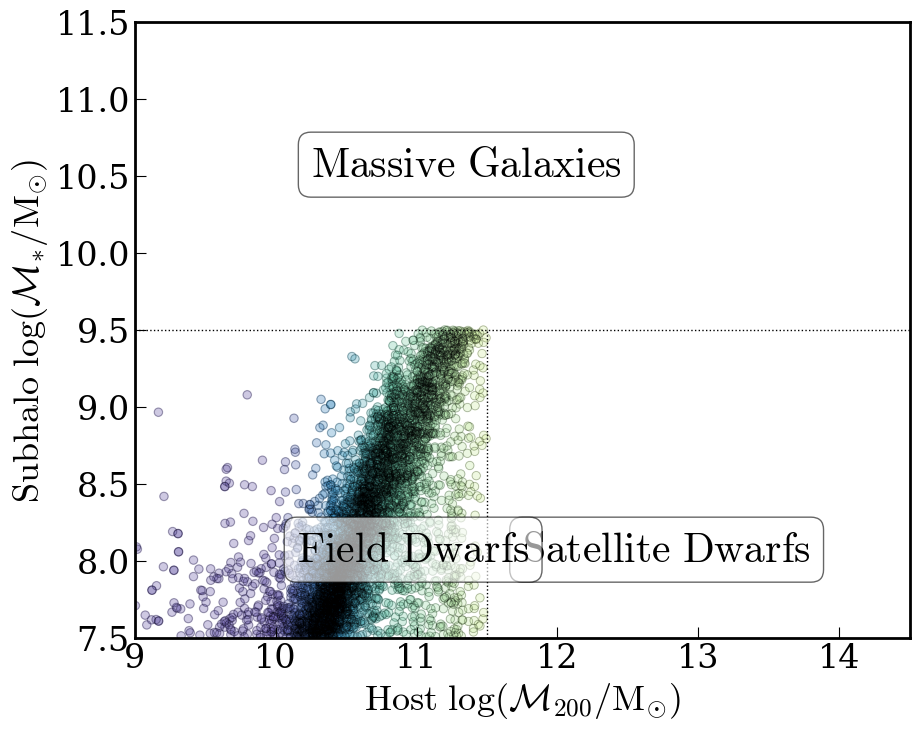

In [35]:
fig,ax=plt.subplots(figsize=(10,8))

ax.scatter(m200_a,mst_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.3)
ax.scatter(m200_a[dw_samp],mst_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.3)

ax.set_xlim((9,14.5))
ax.set_ylim((7.5,11.5))
ax.axhline(9.5,ls=':',lw=1,color='black')
ax.axvline(11.5,ymax=0.5,ls=':',lw=1,color='black')

ax.text(10.25,10.5,r'$Massive\ Galaxies$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(11.75,8,r'$Satellite\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(10.15,8,r'$Field\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))

ax.set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax.set_ylabel(r'$Subhalo\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=26)
ax.set_rasterized(True)


375 5843


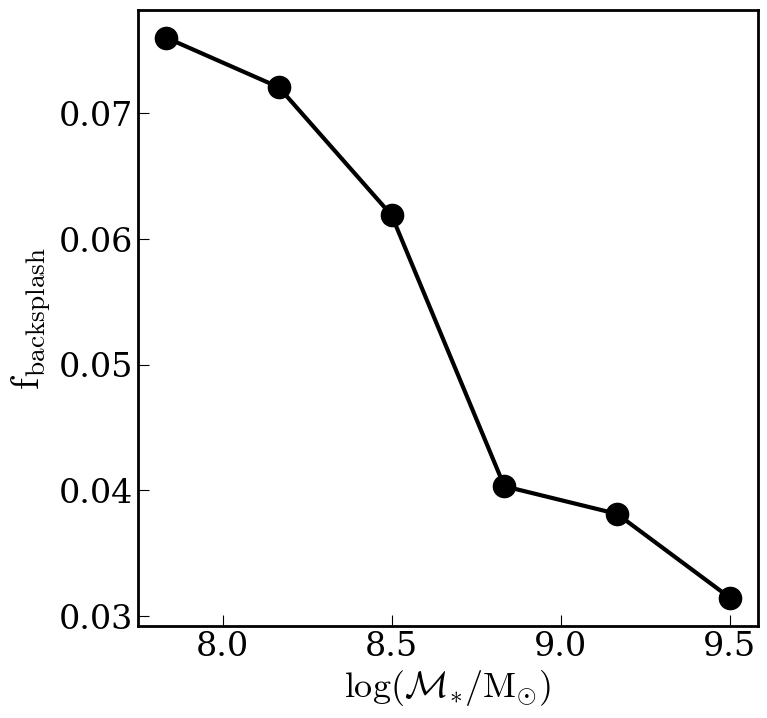

In [27]:
fig,ax=plt.subplots(figsize=(8,8),sharex=True)

mst_bins = np.linspace(7.5,9.5,7)
mst_bw = 0.5*(mst_bins[1]-mst_bins[0])
    
back_hist, bin_edg = np.histogram(gls.sub.mst[llg[2]],bins=mst_bins)
all_hist, bin_edg = np.histogram(mst_a, bins=mst_bins)

print(np.sum(back_hist),np.sum(all_hist))
    
#np.histogram(back_arr[:,0],weights=back_arr[:,1],bins=)
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
ax.plot(bin_edg[:-1]+mst_bw,back_hist/(back_hist+all_hist),color='black',lw=3,marker='o',markersize=16)

ax.set_xlabel(r'$log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=26)
ax.set_ylabel(r'$f_{backsplash}$',fontsize=28)

plt.savefig('fracbacksplash.pdf',bbox_inches='tight')


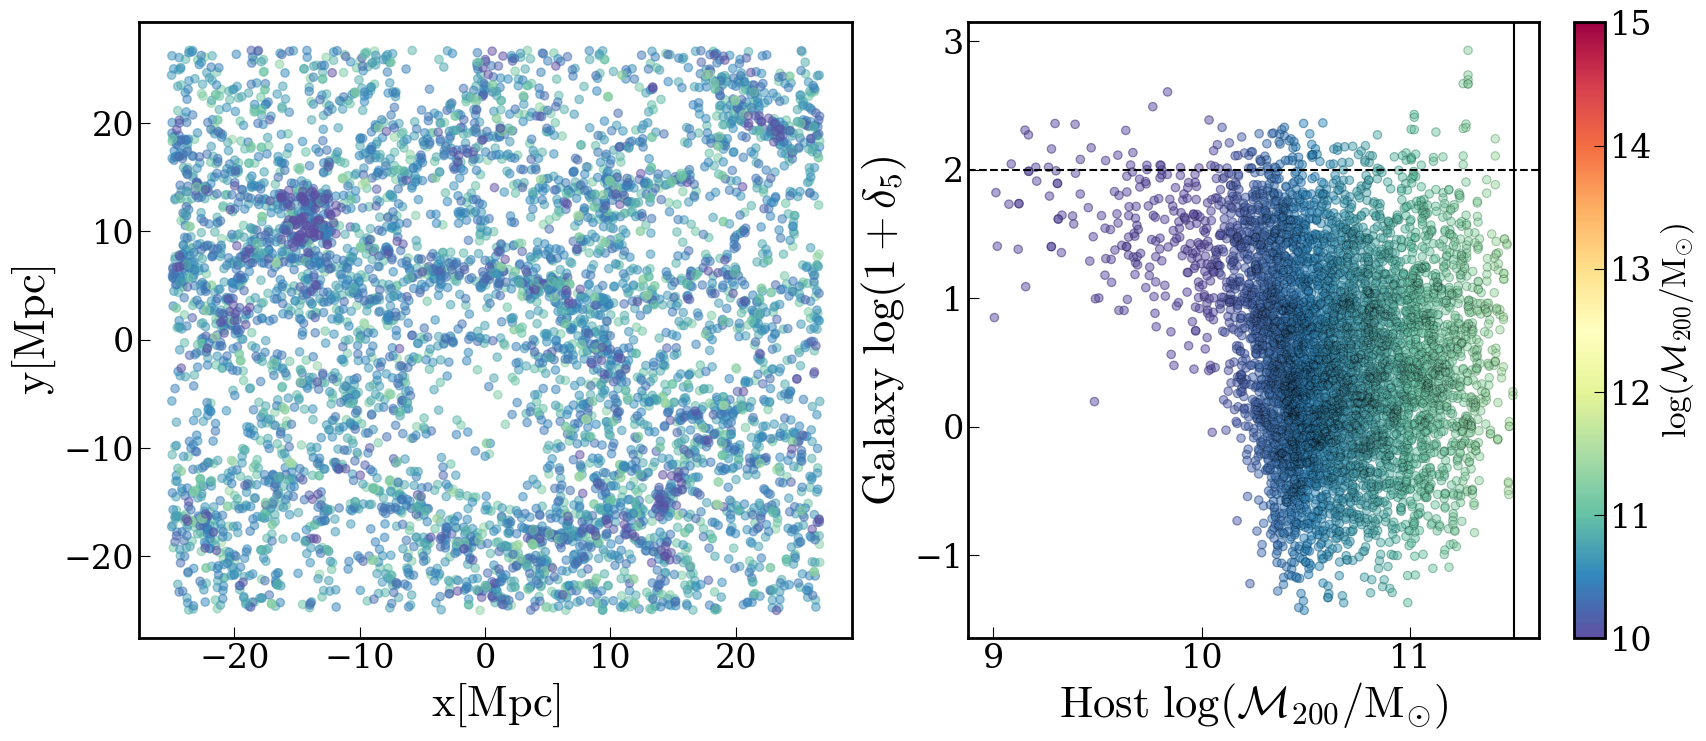

In [36]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.075,0.46,0.005])

ax[0].scatter(x_a,y_a,marker='o',c=gls.hst.group_m200[llh_a],cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)

ax[0].set_xlabel(r'$x[Mpc]$',fontsize=32)
ax[0].set_ylabel(r'$y[Mpc]$',fontsize=32)

ax[2].scatter(m200_a,llr_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)
ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.2)

ax[2].axvline(11.5,color='black')
ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=15),cmap=mcm.Spectral_r), ax=ax[2], orientation='vertical',label=r'$log(\mathcal{M}_{200}/M_{\odot})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)


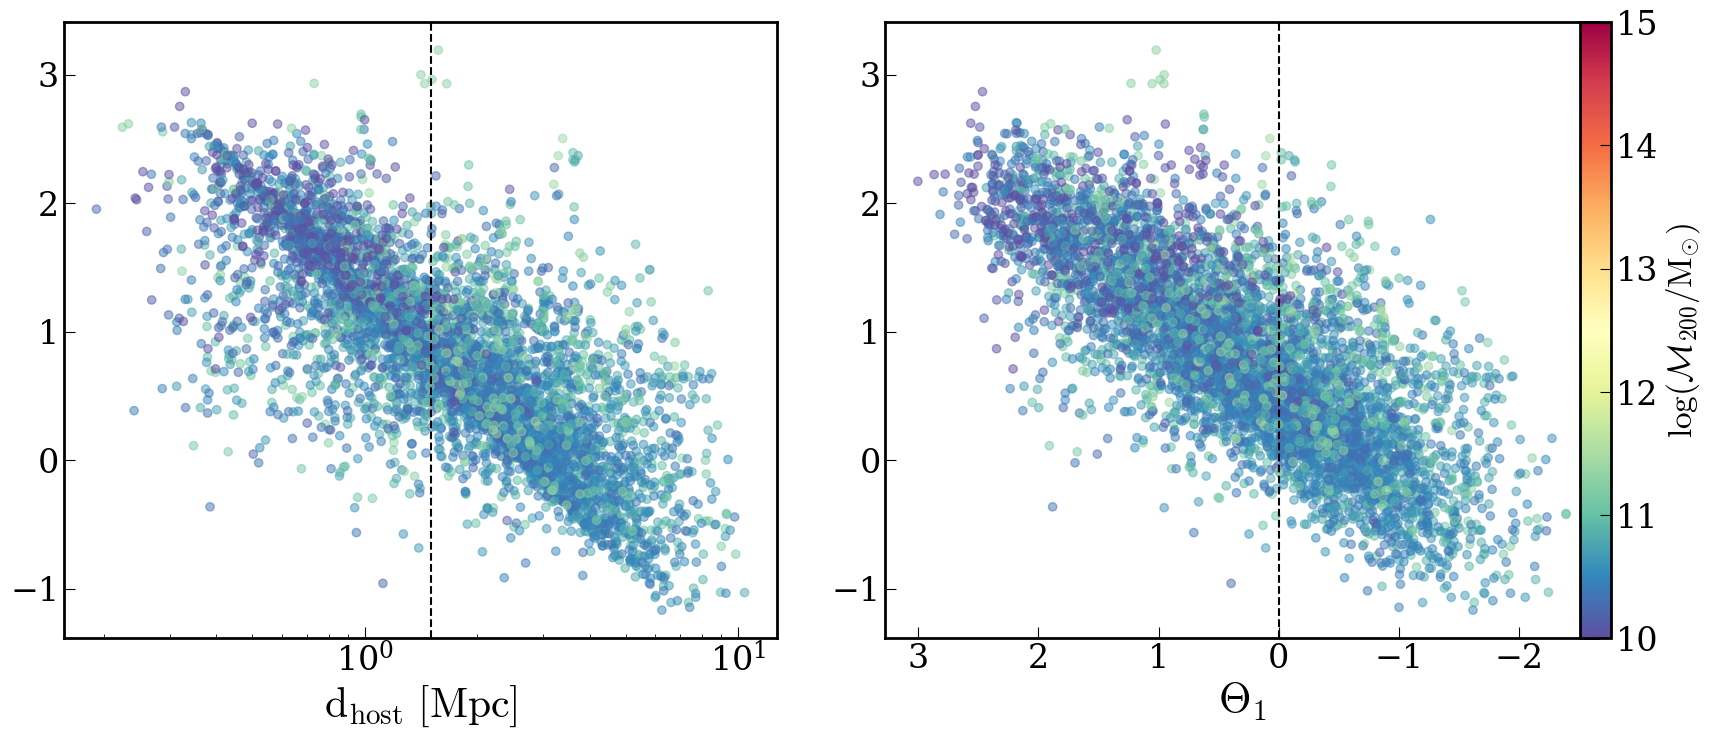

In [28]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.07,0.46,0.01])

#dens_srt = np.sort(llr_a)
#print(dens_srt)
#den_scr = sts.percentileofscore(dens_srt,llr_a)

ax[0].scatter(dhost_a,llr_a,c=gls.hst.group_m200[llh_a],cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)
ax[2].scatter(llt_a,llr_a,c=gls.hst.group_m200[llh_a],cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)

#ax[0].set_xlim((7,9.5))
#ax[0].set_xlabel(r'$log(1+\delta_5)$',fontsize=30)
#ax[2].set_xlabel(r'$log(1+\delta_5)$',fontsize=30)
ax[2].set_xlabel(r'$\Theta_1$',fontsize=30)
ax[0].set_xlabel(r'$d_{host}\ [Mpc]$',fontsize=30)

ax[0].set_xscale('log')
ax[2].invert_xaxis()

ax[0].axvline(1.5,color='black',ls='--')
ax[2].axvline(0,color='black',ls='--')

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=15),cmap=mcm.Spectral_r), ax=ax[3], orientation='vertical',fraction=2.2,label=r'$log(\mathcal{M}_{200}/M_{\odot})$')
ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('tidal_mst.pdf',bbox_inches='tight')

In [11]:
def lin_scale(x,vmin,vmax):
    y = (x-vmin)/(vmax-vmin)
    y[np.where(y>1)[0]] = 1
    y[np.where(y<0)[0]] = 0
    
    return y

In [38]:
print(min(llr_a),max(llr_a),np.median(llr_a))
print(min(dhost_a),max(dhost_a),np.median(dhost_a))
print(min(llt_a),max(llt_a),np.median(llt_a))

-1.4305908069815438 2.927191558749317 0.5232759902605293
0.19096607333920274 10.398552974114022 1.6925952133617141
-2.3933797461182316 3.0042351526636146 0.25962631467862707


In [39]:
dsfms_a = ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a))
red = np.where(dsfms_a<0)[0]
blue = np.where(dsfms_a>=0)[0]

print('Overall QF:',100*len(red)/(len(red)+len(blue)))

#print(len(dw_samp),len(red),len(blue))
print('dhost field QF:',100*len(np.where(dhost_a[red]>=1.5)[0])/(len(np.where(dhost_a[red]>=1.5)[0])+len(np.where(dhost_a[blue]>=1.5)[0])))
print('theta1 field QF:',100*len(np.where(llt_a[red]<0)[0])/(len(np.where(llt_a[red]<0)[0])+len(np.where(llt_a[blue]<0)[0])))

print(len(np.where(dhost_a[red]<1.5)[0])/len(red),len(np.where(llt_a[red]>=0)[0])/len(red))
print(len(np.where(dhost_a[blue]>=1.5)[0])/len(blue),len(np.where(llt_a[blue]<0)[0])/len(blue))

Overall QF: 7.581721718295396
dhost field QF: 1.289134438305709
theta1 field QF: 1.2668918918918919
0.9051918735891648 0.9322799097065463
0.5955555555555555 0.43296296296296294


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0 0.022186687987207677
1 0.04946236559139785
2 0.824


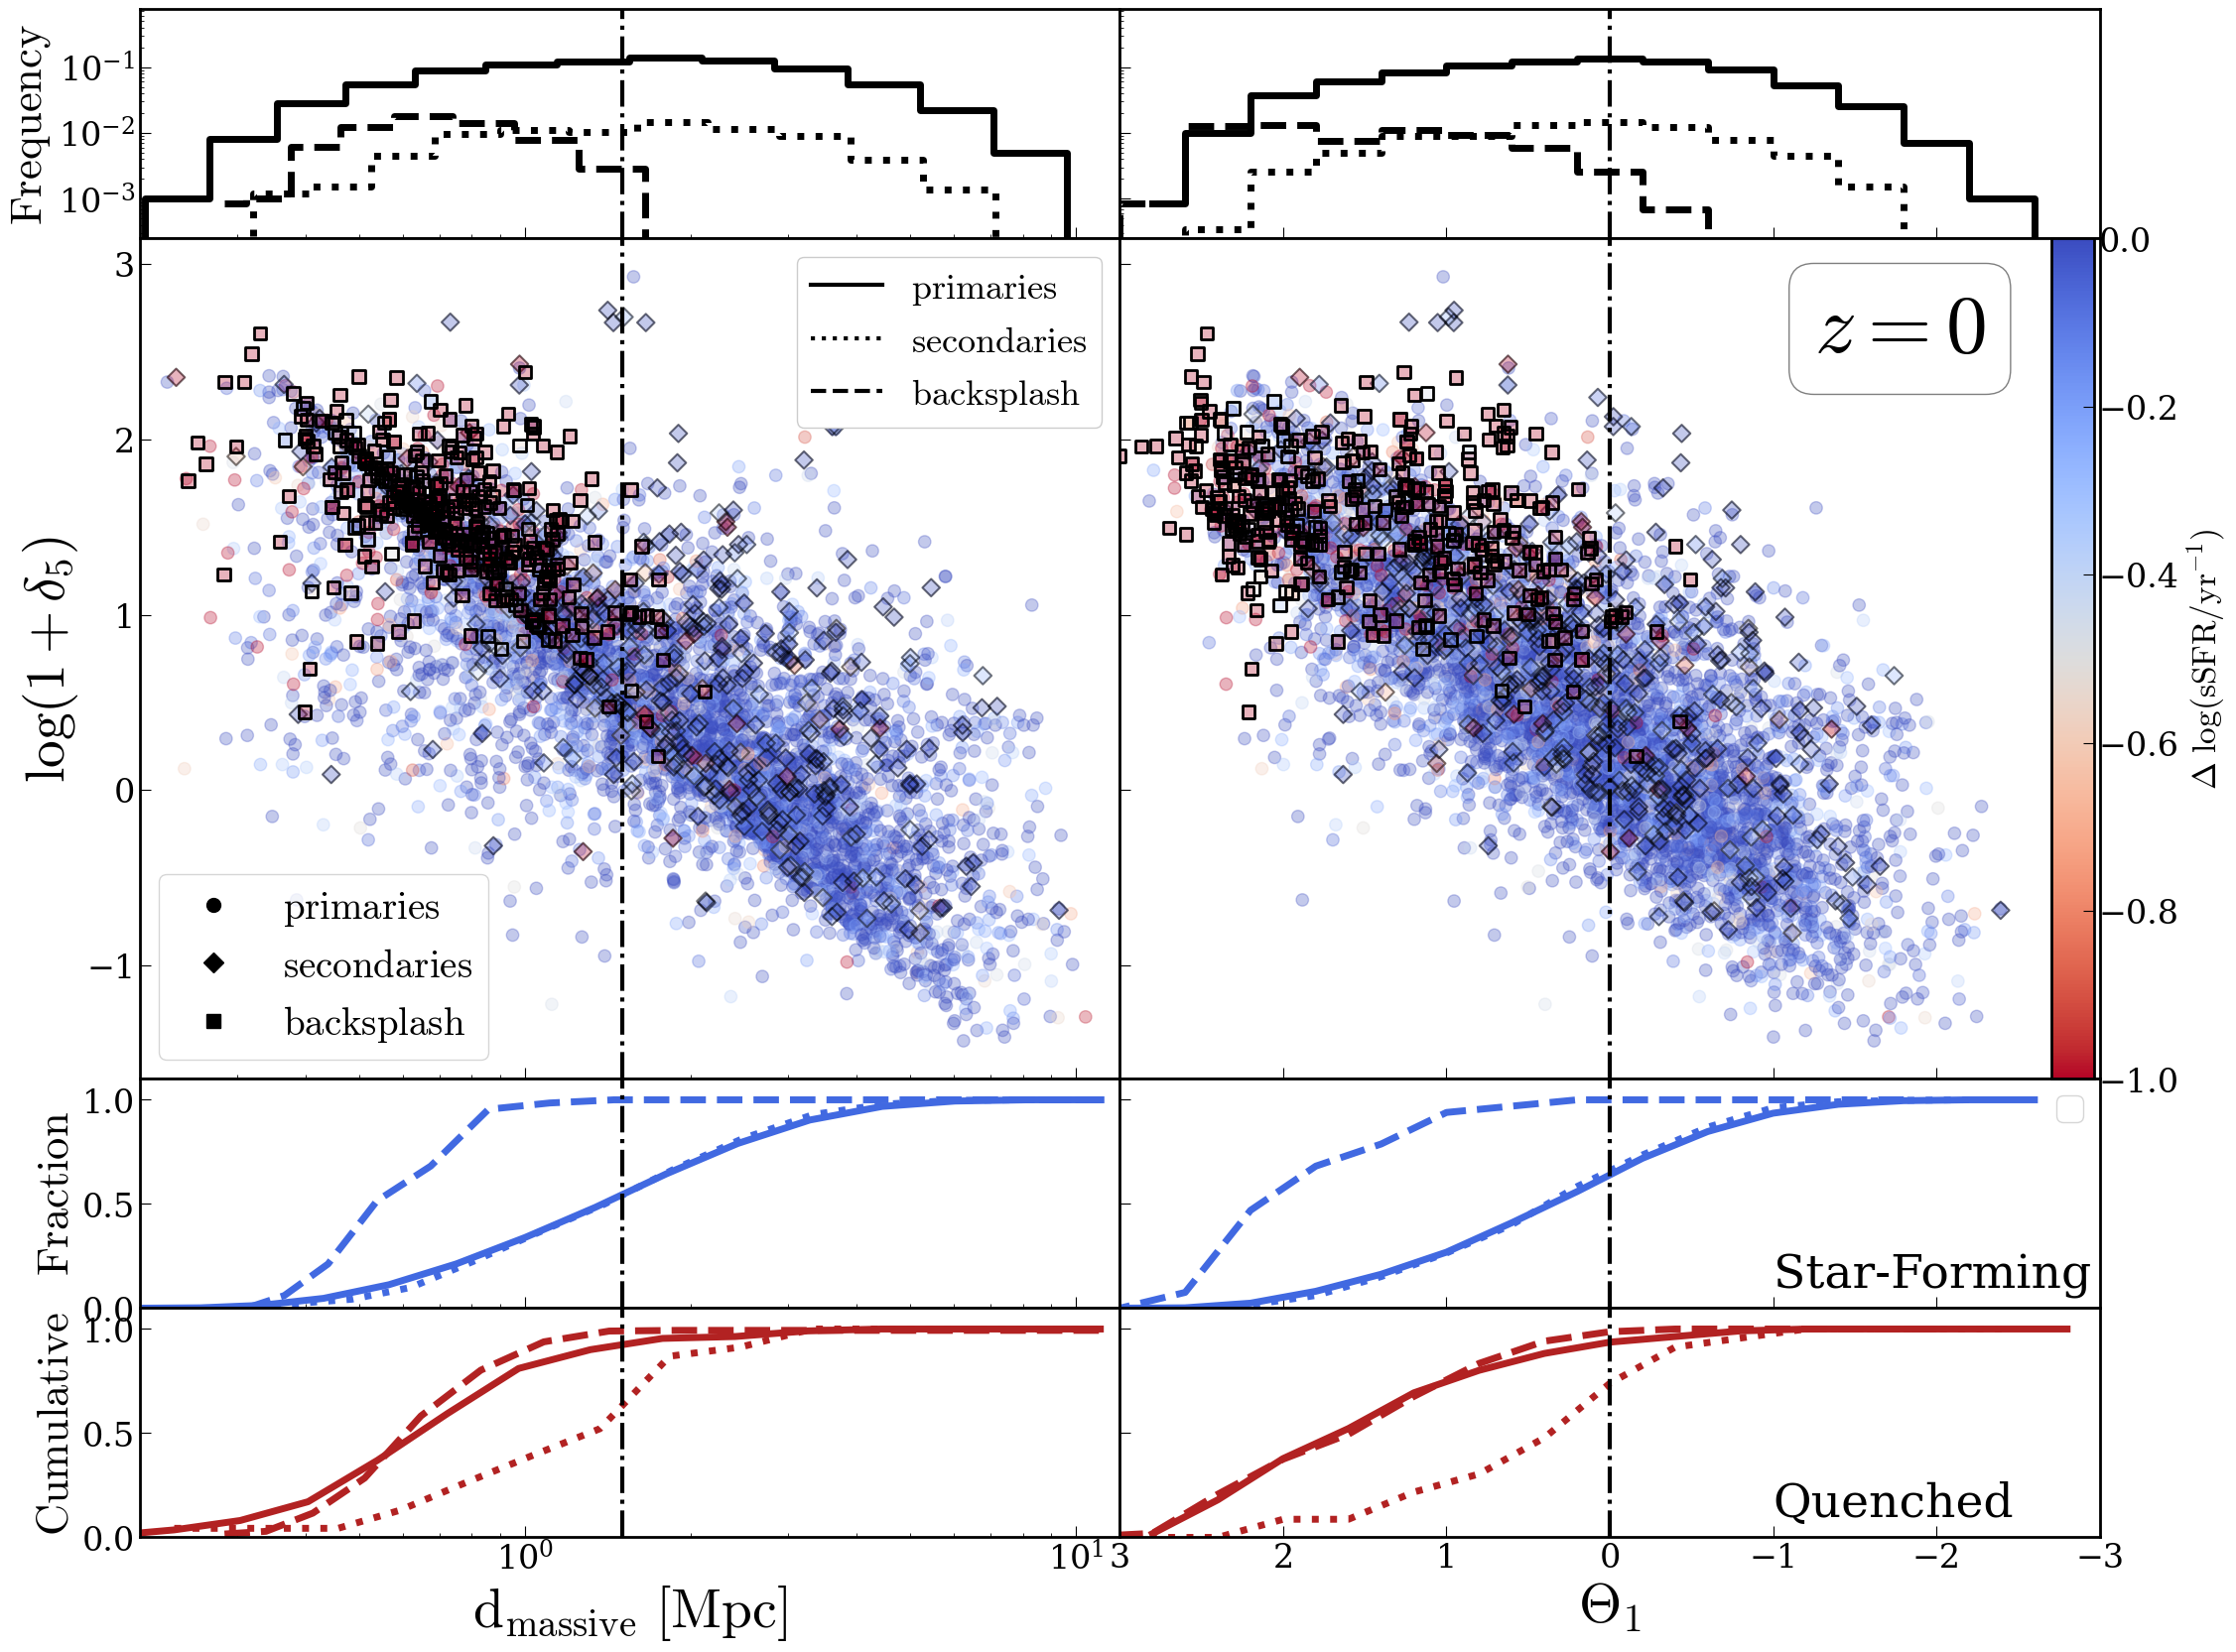

In [46]:
fig,ax=plt.subplots(4,3,figsize=(26,20),sharey='row',sharex='col',width_ratios=[0.49,0.49,0.02],height_ratios=[0.15,0.55,0.15,0.15])

tracer_bins1 = [np.logspace(np.log10(0.15),np.log10(15),16),np.linspace(-3,3,16)]
tracer_bw1 = [0.5*(tb[1]-tb[0]) for tb in tracer_bins1]
bin_ls = ['-',':','--']


'''
bin_sat, bin_edg = np.histogram(dhost_a[red],bins=tracer_bins1[0])
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
bin_sat=np.cumsum(bin_sat)/len(red)
print(bin_sat)
ax[2,0].plot(bin_edg[:-1],bin_sat,color='firebrick',lw=5)

bin_sat, bin_edg = np.histogram(dhost_a[blue],bins=tracer_bins1[0])
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
bin_sat=np.cumsum(bin_sat)/len(blue)
print(bin_sat)
ax[2,0].plot(bin_edg[:-1],bin_sat,color='royalblue',lw=5)

bin_sat, bin_edg = np.histogram(llt_a[red],bins=tracer_bins1[1])
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
bin_sat=np.cumsum(bin_sat[::-1])[::-1]/len(red)
print(bin_sat)
ax[2,1].plot(bin_edg[:-1],bin_sat,color='firebrick',lw=5,label='Quenched')

bin_sat, bin_edg = np.histogram(llt_a[blue],bins=tracer_bins1[1])
bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
bin_sat=np.cumsum(bin_sat[::-1])[::-1]/len(blue)
print(bin_sat)
ax[2,1].plot(bin_edg[:-1],bin_sat,color='royalblue',lw=5,label='Star-forming')
'''

ax[2,1].legend(loc='best',fontsize=24,framealpha=0.8,frameon=True)

for k in range(3):
    llt_b = np.array([t for t in llt[k]])
    dhost_b = np.array([d for d in dhost[k]])
    llr_b = np.log10(np.array([r for r in llr[k]])) - np.log10(0.142904)

    bin_sat, bin_edg = np.histogram(dhost_b,bins=tracer_bins1[0])
    ax[0,0].step(tracer_bins1[0][:-1]+tracer_bw1[0],bin_sat/np.sum(N_lll),color='black',ls=bin_ls[k],lw=5,where='mid')

    bin_sat, bin_edg = np.histogram(llt_b,bins=tracer_bins1[1])
    ax[0,1].step(tracer_bins1[1][:-1]+tracer_bw1[1],bin_sat/np.sum(N_lll),color='black',ls=bin_ls[k],lw=5,where='mid')
    
    ssfr_b = np.array([s for s in gls.sub.ssfr[llg[k]]])
    mst_b = np.array([m for m in gls.sub.mst[llg[k]]])
    dsfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))
    red = np.where(dsfms_b<-1)[0]
    blue = np.where(dsfms_b>=-1)[0]
    print(k,len(red)/(len(red)+len(blue)))

    ax[1,0].scatter(dhost_b,llr_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80)
    ax[1,1].scatter(llt_b,llr_b,c=dsfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.3,marker=bin_mk[k],s=80)

    if k==1:
        ax[1,0].scatter(dhost_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80) 
        ax[1,1].scatter(llt_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80) 

    if k==2:
        ax[1,0].scatter(dhost_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80) 
        ax[1,1].scatter(llt_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80)  


    bin_sat, bin_edg = np.histogram(dhost_b[red],bins=tracer_bins1[0])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat)/len(red)
    #print(bin_sat)
    ax[3,0].plot(bin_edg[:-1],bin_sat,color='firebrick',lw=5,ls=bin_ls[k])
    
    bin_sat, bin_edg = np.histogram(dhost_b[blue],bins=tracer_bins1[0])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat)/len(blue)
    #print(bin_sat)
    ax[2,0].plot(bin_edg[:-1],bin_sat,color='royalblue',lw=5,ls=bin_ls[k])
    
    bin_sat, bin_edg = np.histogram(llt_b[red],bins=tracer_bins1[1])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat[::-1])[::-1]/len(red)
    #print(bin_sat)
    ax[3,1].plot(bin_edg[:-1],bin_sat,color='firebrick',lw=5,ls=bin_ls[k])
    
    bin_sat, bin_edg = np.histogram(llt_b[blue],bins=tracer_bins1[1])
    bin_edg+=0.5*(bin_edg[1]-bin_edg[0])
    bin_sat=np.cumsum(bin_sat[::-1])[::-1]/len(blue)
    #print(bin_sat)
    ax[2,1].plot(bin_edg[:-1],bin_sat,color='royalblue',lw=5,ls=bin_ls[k])

    
#ax[0].scatter(dhost_a[dw_samp],llr_a[dw_samp],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.2,marker=binmk_a[dw_samp])
#ax[2].scatter(llt_a[dw_samp],llr_a[dw_samp],c=dsfms_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.2,marker=binmk_a[dw_samp])

custom_lines = [Line2D([0], [0],lw=3,ls=bin_ls[0], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[1], color='black'), Line2D([0], [0],lw=3,ls=bin_ls[2], color='black')]
leg=Legend(ax[1,0],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='upper right',fontsize=26,frameon=True,framealpha=1.0)
ax[1,0].add_artist(leg)

custom_lines = [Line2D([0], [0],lw=3,ls='none',marker=bin_mk[0], color='black',markersize=10), Line2D([0], [0],lw=3,ls='none',marker=bin_mk[1], color='black',markersize=10), Line2D([0], [0],lw=3,ls='none',marker=bin_mk[2], color='black',markersize=10)]
leg=Legend(ax[1,0],custom_lines,[r'$primaries$',r'$secondaries$',r'$backsplash$'],loc='best',fontsize=28,framealpha=0.8,frameon=True)
ax[1,0].add_artist(leg)


ax[2,1].text(-1,0.1,'Star-Forming',fontsize=34)
ax[3,1].text(-1,0.1,'Quenched',fontsize=34)

#ax[0].set_xlim((7,9.5))
ax[1,0].set_ylabel(r'$log(1+\delta_5)$',fontsize=40)
ax[2,0].set_ylabel(r'$Fraction$',fontsize=32)
ax[3,0].set_ylabel(r'$Cumulative$',fontsize=32)
ax[3,1].set_xlabel(r'$\Theta_1$',fontsize=40)
ax[3,0].set_xlabel(r'$d_{massive}\ [Mpc]$',fontsize=40)
ax[0,0].set_ylabel(r'$Frequency$',fontsize=32)

ax[0,1].invert_xaxis()
ax[2,1].invert_xaxis()

for k in range(4):
    ax[k,0].set_xscale('log')
    ax[k,0].axvline(1.5,color='black',ls='-.',lw=3)
    ax[k,1].axvline(0,color='black',ls='-.',lw=3)
    ax[k,2].set_axis_off()

for k in range(2):
    #ax[0,k].set_axis_off()
    ax[0,k].set_yscale('log')
    ax[0,k].set_ylim(2.5e-4,0.75)
    #x[2,k].set_yscale('log')
    ax[2,k].set_ylim(0.0,1.1)
    ax[3,k].set_ylim(0.0,1.1)
    ax[1,k].set_rasterized(True)

ax[1,1].text(-1.25,2.5,r'${\it z=0}$',fontsize=60,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))
ax[1,0].set_xlim((0.2,12))
ax[1,1].set_xlim((3,-3))

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[1,2], orientation='vertical',fraction=2.2,label=r'$\Delta\ log(sSFR/yr^{-1})$')
plt.subplots_adjust(wspace=0.0,hspace=0.0)
plt.savefig('env_dssfr.pdf',bbox_inches='tight')